In [19]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd


import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import ART_downscale as ART_down

import warnings
warnings.filterwarnings('ignore')

In [20]:
# product, time_reso = 'IMERG', '1dy'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'CHIRPS', '1dy'

# product, time_reso = 'ERA5', '3h'

# product, time_reso = 'MSWEP', '3h'
product, time_reso = 'GSMaP', '3h'

In [21]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy')
obs_base = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [22]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

In [23]:
data_dir = os.path.join(dir_base, 'Satellite','5_DOWN', f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(data_dir)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
years = DATA.year.values

In [24]:
METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy_CLEAR.csv'))
print(f'Number of Stations: {len(METADATA)}')

Number of Stations: 2919


In [25]:
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

lon_list, lat_list = [], []
SAT_list, DOWN_list = [], []
RE_DOWN_list, RE_SAT_list = [], []
ME_DOWN_list, ME_SAT_list = [], []

for nn in range(len(METADATA)):

    name = METADATA['File'].values[nn]
    ISO = METADATA['ISO'].values[nn]
    lat_obs = METADATA['Lat'].values[nn]
    lon_obs = METADATA['Lon'].values[nn]

    dir_station = os.path.join(dir_base,'Rain_Gauges_QC','Weibull','1dy',ISO,name)
    DF_OBS = pd.read_csv(dir_station)
    DF_OBS = DF_OBS.drop(columns='NaN')

    PREC_DOWN = DATA.sel(lat=lat_obs, lon=lon_obs, method='nearest')

    DF_SAT = pd.DataFrame({
                            'Year':PREC_DOWN.year.values, 
                            'Ns':PREC_DOWN.NYs.values, 'Cs':PREC_DOWN.CYs.values, 'Ws':PREC_DOWN.WYs.values,
                            'Nd':PREC_DOWN.NYd.values, 'Cd':PREC_DOWN.CYd.values, 'Wd':PREC_DOWN.WYd.values})

    merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

    merged_df_clean = merged_df.dropna(subset=['N'])
    
    if merged_df_clean.Ns.values.sum() == 0 or np.isnan(merged_df_clean.Ns.values.sum()) == True:
        lon_list.append(np.nan)
        lat_list.append(np.nan)
        SAT_list.append(np.nan)
        DOWN_list.append(np.nan)
        RE_SAT_list.append(np.nan)
        RE_DOWN_list.append(np.nan)
        ME_SAT_list.append(np.nan)
        ME_DOWN_list.append(np.nan)

    else:
        x0 = 9.0*np.nanmean(merged_df_clean.C.values)
        quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.N.values, merged_df_clean.C.values, merged_df_clean.W.values, thresh=1)
        QQ_OBS = np.where(flag, quant, np.nan)

        x0 = 9.0*np.nanmean(merged_df_clean.Cs.values)
        quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Ns.values, merged_df_clean.Cs.values, merged_df_clean.Ws.values, thresh=1)
        QQ_SAT = np.where(flag, quant, np.nan)

        x0 = 9.0*np.nanmean(merged_df_clean.Cd.values)
        quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Nd.values, merged_df_clean.Cd.values, merged_df_clean.Wd.values, thresh=1)
        QQ_DOWN = np.where(flag, quant, np.nan)

        RE_SAT = (QQ_SAT - QQ_OBS) / QQ_OBS
        RE_DOWN = (QQ_DOWN - QQ_OBS) / QQ_OBS
        
        ME_SAT = QQ_SAT/QQ_OBS
        ME_DOWN = QQ_DOWN/QQ_OBS

        lon_list.append(lon_obs)
        lat_list.append(lat_obs)
        SAT_list.append(QQ_SAT[3])
        DOWN_list.append(QQ_DOWN[3])
        RE_SAT_list.append(RE_SAT[3])
        RE_DOWN_list.append(RE_DOWN[3])
        ME_SAT_list.append(ME_SAT[3])
        ME_DOWN_list.append(ME_DOWN[3])

PD_RE  = pd.DataFrame({'Lon':lon_list,'Lat':lat_list, 'Mevd_SAT':SAT_list, 'Mevd_DOWN':DOWN_list, 'RE_SAT':RE_SAT_list, 'RE_DOWN':RE_DOWN_list, 'ME_SAT':ME_SAT_list, 'ME_DOWN':ME_DOWN_list})

dir_out = os.path.join('..','..','output','RE',f'RE_{product}.csv')
PD_RE.to_csv(dir_out, header=True, index=None)

In [26]:
scatter_cmap = 'coolwarm_r'

RE_levels = np.arange(-1,1.1,0.1)
RE_norm = mcolors.BoundaryNorm(boundaries=RE_levels, ncolors=256)
RE_ticks = np.arange(-1,1.2,0.2)

ME_levels = np.arange(0,2.1,0.1)
ME_norm = mcolors.BoundaryNorm(boundaries=ME_levels, ncolors=256)
ME_ticks = np.arange(0,2.2,0.2)

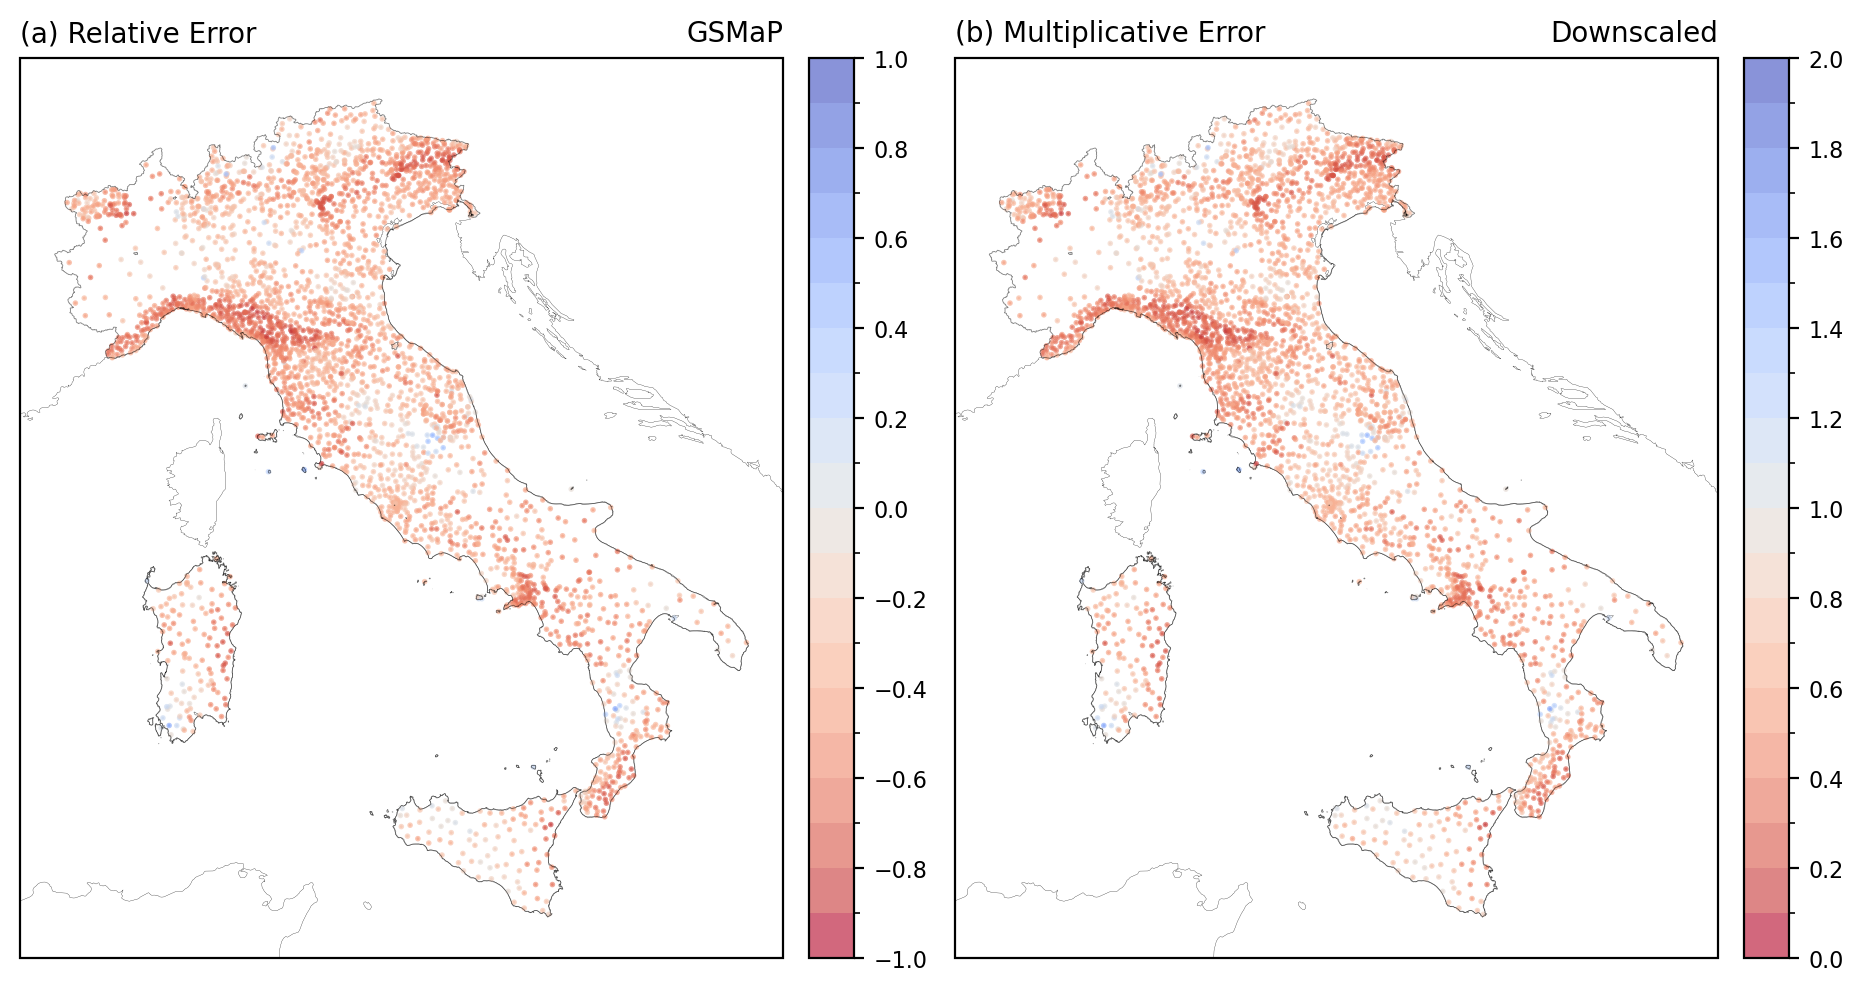

In [27]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10,5),dpi=200)
gs = gridspec.GridSpec(1,2)

# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)

a1 = ax1.scatter(
    PD_RE['Lon'],
    PD_RE['Lat'],
    c=PD_RE['RE_DOWN'],
    cmap=scatter_cmap,
    s=1,
    norm=RE_norm,
    alpha=0.6,
    zorder=20
    )

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03, ticks=RE_ticks)
cbar.ax.tick_params(labelsize=8)

ax1.set_title('(a) Relative Error',fontsize=10, loc='left')
ax1.set_title(product,fontsize=10, loc='right')

# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)

a1 = ax1.scatter(
    PD_RE['Lon'],
    PD_RE['Lat'],
    c=PD_RE['ME_DOWN'],
    cmap=scatter_cmap,
    s=1,
    norm=ME_norm,
    alpha=0.6,
    zorder=20
    )

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03, ticks=ME_ticks)
cbar.ax.tick_params(labelsize=8)

ax1.set_title('(b) Multiplicative Error',fontsize=10, loc='left')
ax1.set_title('Downscaled',fontsize=10, loc='right')

# ======================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.08, hspace=0.13)

dir_out = os.path.join('..','..','figure','RE',f'DOWN_RE_ME_{product}.png')
plt.savefig(dir_out,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)